In [1]:
# Turkey Macro Dashboard
# ==========================================
# Author: Osman Manay
# Date: 2026
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# ARIMA için
try:
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.stattools import adfuller
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    print("✅ statsmodels hazır!")
except:
    !pip install statsmodels -q
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.stattools import adfuller

# Grafik ayarları
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style("white")

# Renkler
RED = '#e31937'
BLUE = '#003087'
GREEN = '#047857'
ORANGE = '#f59e0b'
PURPLE = '#7c3aed'
GRAY = '#666666'

print("✅ Tüm kütüphaneler hazır!")
print("🇹🇷 Turkey Macro Dashboard başlıyor...")

✅ statsmodels hazır!
✅ Tüm kütüphaneler hazır!
🇹🇷 Turkey Macro Dashboard başlıyor...


In [2]:
# ==========================================
# TÜRKİYE 10 YILLIK MAKROEKONOMİK VERİ
# ==========================================

data = {
    'year': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],

    # Enflasyon
    'cpi': [7.67, 8.53, 11.92, 20.30, 15.18, 14.60, 19.60, 72.31, 64.77, 44.38, 30.10],
    'ppi': [5.71, 9.94, 15.47, 33.64, 7.36, 25.15, 43.96, 97.72, 44.22, 33.90, 25.40],

    # Döviz
    'usd_try': [2.72, 3.52, 3.65, 5.29, 5.68, 7.44, 13.32, 18.85, 29.51, 32.90, 38.20],
    'eur_try': [2.97, 3.71, 4.12, 6.13, 6.36, 8.80, 15.67, 19.88, 32.30, 35.60, 41.50],

    # İşsizlik
    'unemployment': [10.3, 10.9, 10.9, 11.0, 13.7, 13.2, 12.0, 10.5, 9.4, 8.5, 8.2],

    # Büyüme & Faiz
    'gdp_growth': [6.1, 3.2, 7.5, 3.0, -0.1, 1.8, 11.4, 5.6, 4.5, 3.2, 3.8],
    'policy_rate': [7.5, 8.0, 8.0, 24.0, 12.0, 17.0, 14.0, 9.0, 42.5, 50.0, 46.0],
    'real_rate': [-0.17, -0.53, -3.92, 3.70, -3.18, 2.40, -5.60, -63.31, -22.27, 5.62, 15.90]
}

df = pd.DataFrame(data)
df['date'] = pd.to_datetime(df['year'], format='%Y')
df.set_index('date', inplace=True)

# Temel istatistikler
print("=" * 60)
print("📊 TÜRKİYE MAKROEKONOMİK VERİ (2015-2025)")
print("=" * 60)
print(f"\n📈 ENFLASYON (CPI):")
print(f"   Ortalama  : {df['cpi'].mean():.1f}%")
print(f"   Minimum   : {df['cpi'].min():.1f}% ({df['cpi'].idxmin().year})")
print(f"   Maksimum  : {df['cpi'].max():.1f}% ({df['cpi'].idxmax().year})")

print(f"\n💱 USD/TRY:")
print(f"   Başlangıç : {df['usd_try'].iloc[0]:.2f} (2015)")
print(f"   Bitiş     : {df['usd_try'].iloc[-1]:.2f} (2025)")
print(f"   Toplam    : {((df['usd_try'].iloc[-1]/df['usd_try'].iloc[0])-1)*100:.1f}% değer kaybı")

print(f"\n👥 İŞSİZLİK:")
print(f"   Ortalama  : {df['unemployment'].mean():.1f}%")
print(f"   Minimum   : {df['unemployment'].min():.1f}% ({df['unemployment'].idxmin().year})")
print(f"   Maksimum  : {df['unemployment'].max():.1f}% ({df['unemployment'].idxmax().year})")

print(f"\n📊 Korelasyonlar:")
corr_cpi_usd = df['cpi'].corr(df['usd_try'])
corr_cpi_unemp = df['cpi'].corr(df['unemployment'])
corr_usd_unemp = df['usd_try'].corr(df['unemployment'])
print(f"   CPI ↔ USD/TRY      : {corr_cpi_usd:.3f}")
print(f"   CPI ↔ İşsizlik     : {corr_cpi_unemp:.3f}")
print(f"   USD/TRY ↔ İşsizlik : {corr_usd_unemp:.3f}")

📊 TÜRKİYE MAKROEKONOMİK VERİ (2015-2025)

📈 ENFLASYON (CPI):
   Ortalama  : 28.1%
   Minimum   : 7.7% (2015)
   Maksimum  : 72.3% (2022)

💱 USD/TRY:
   Başlangıç : 2.72 (2015)
   Bitiş     : 38.20 (2025)
   Toplam    : 1304.4% değer kaybı

👥 İŞSİZLİK:
   Ortalama  : 10.8%
   Minimum   : 8.2% (2025)
   Maksimum  : 13.7% (2019)

📊 Korelasyonlar:
   CPI ↔ USD/TRY      : 0.675
   CPI ↔ İşsizlik     : -0.465
   USD/TRY ↔ İşsizlik : -0.737


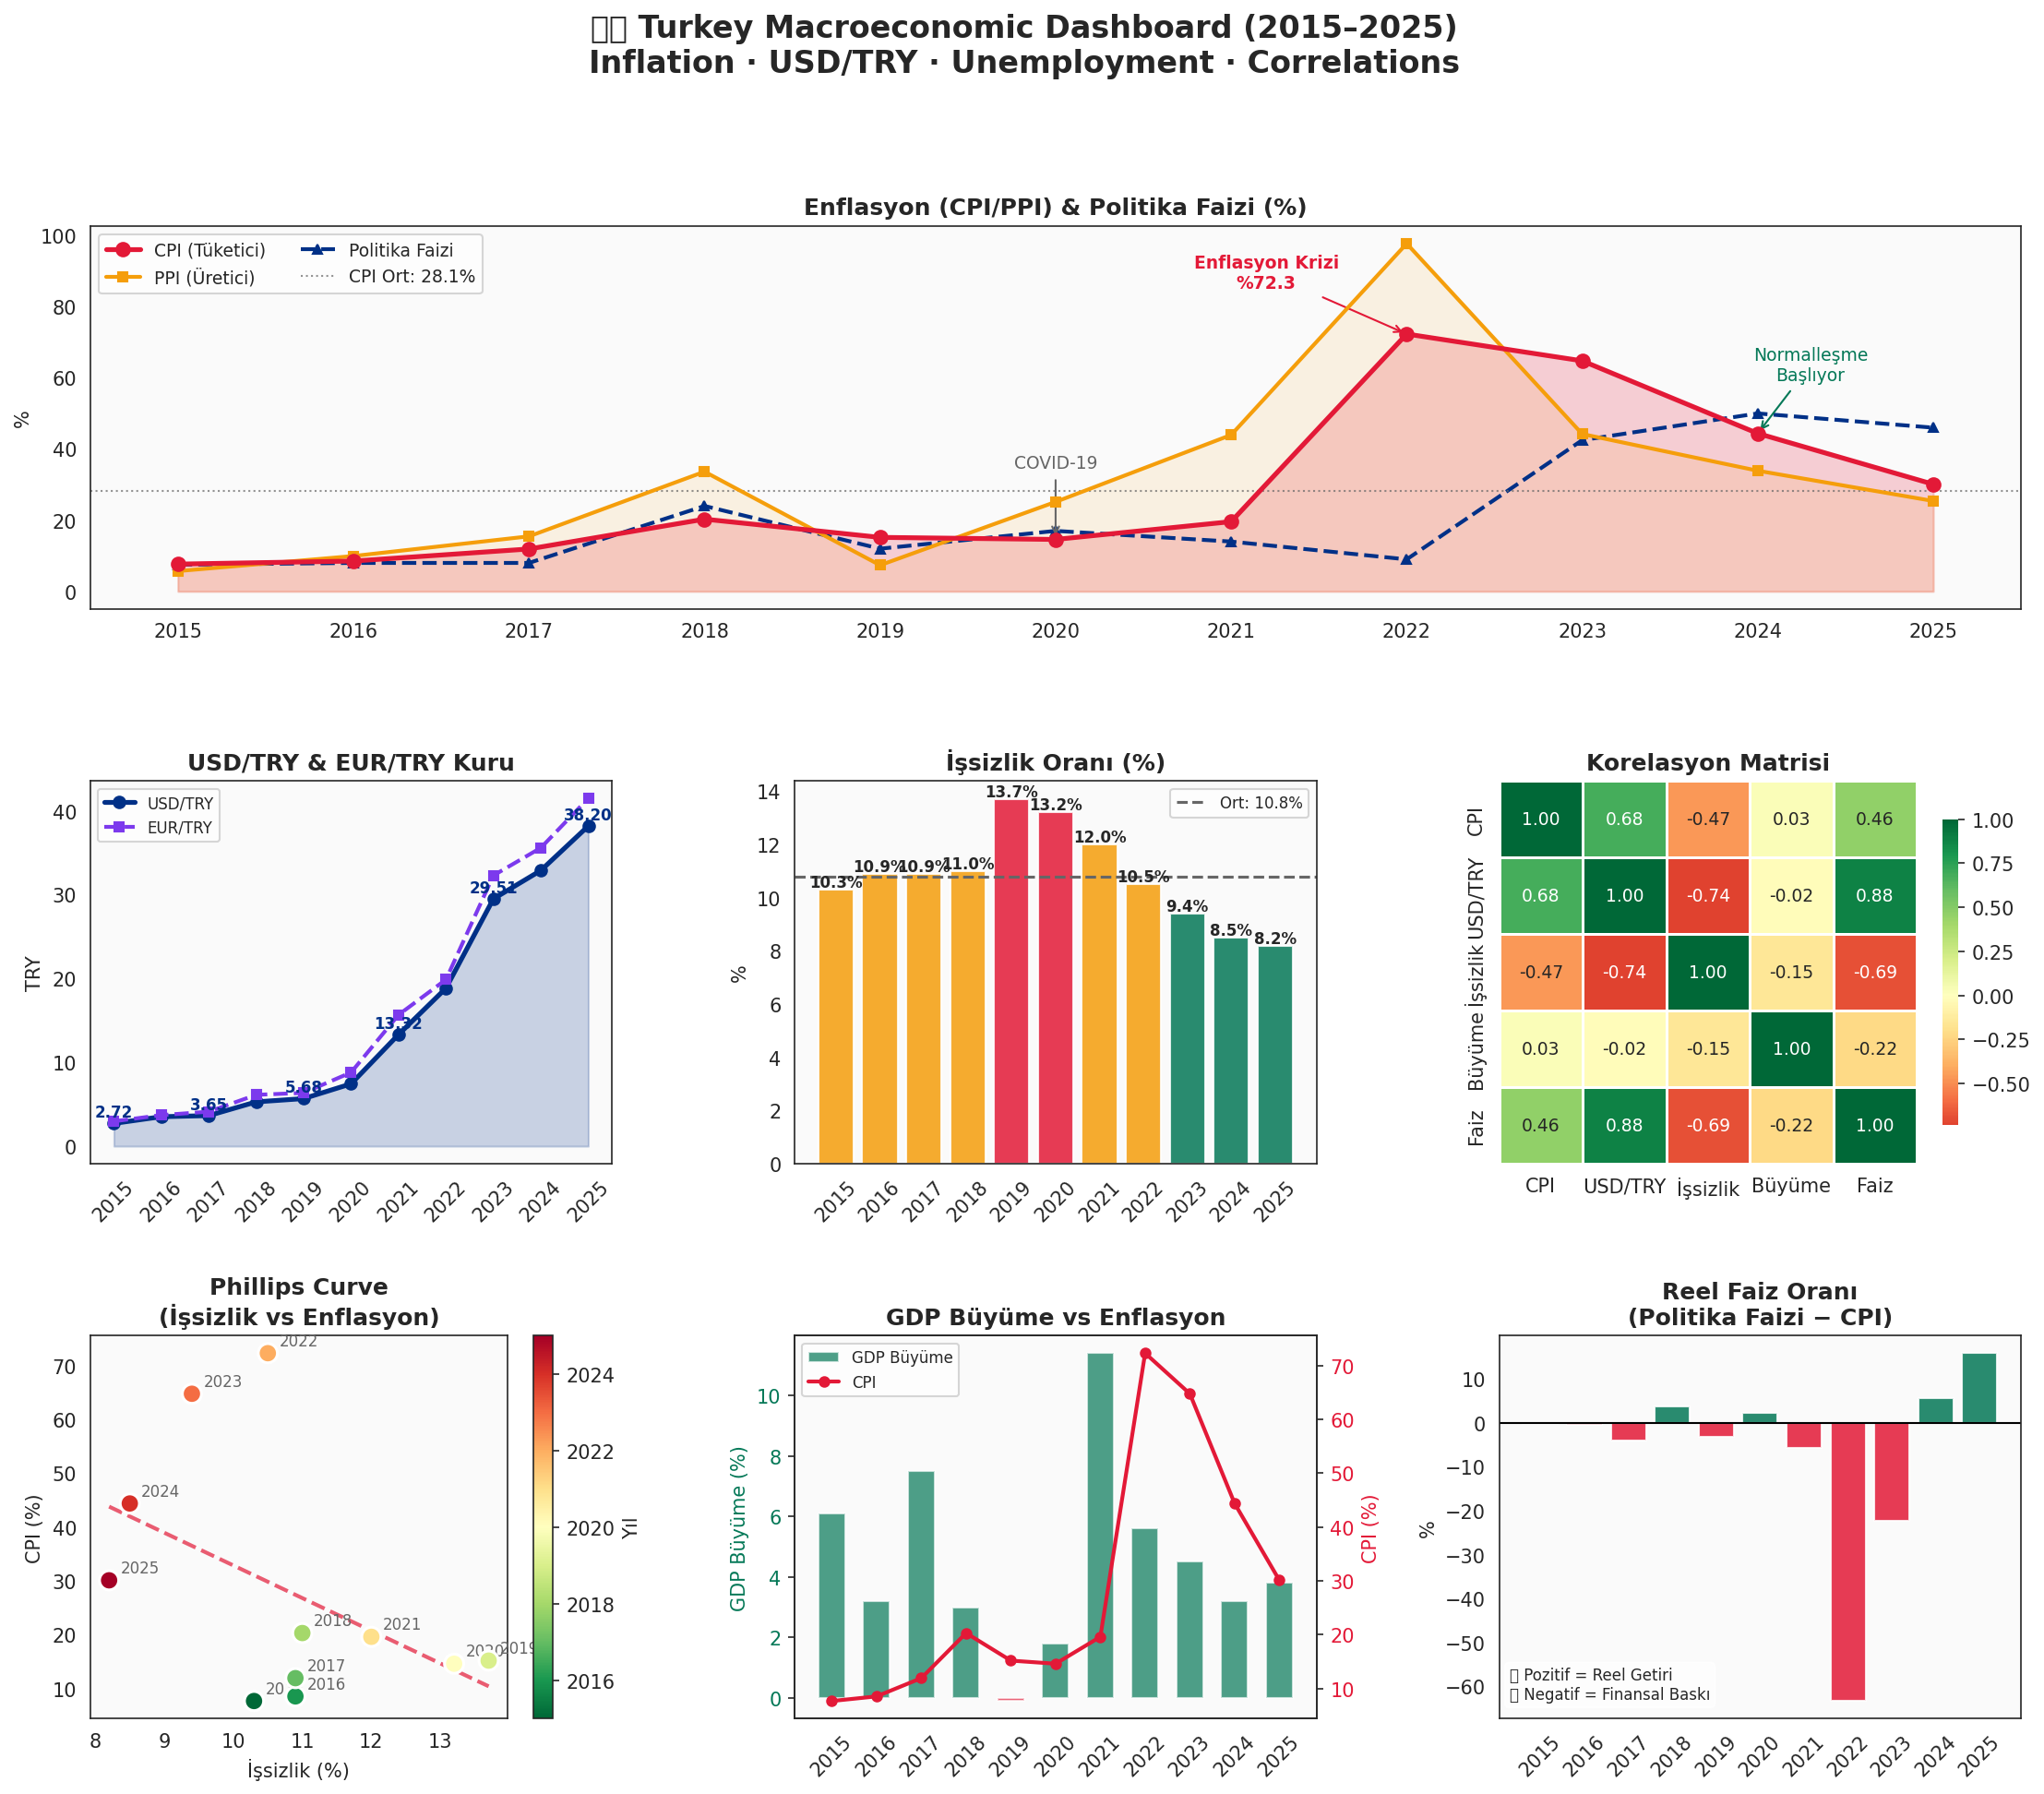

✅ Ana dashboard kaydedildi!


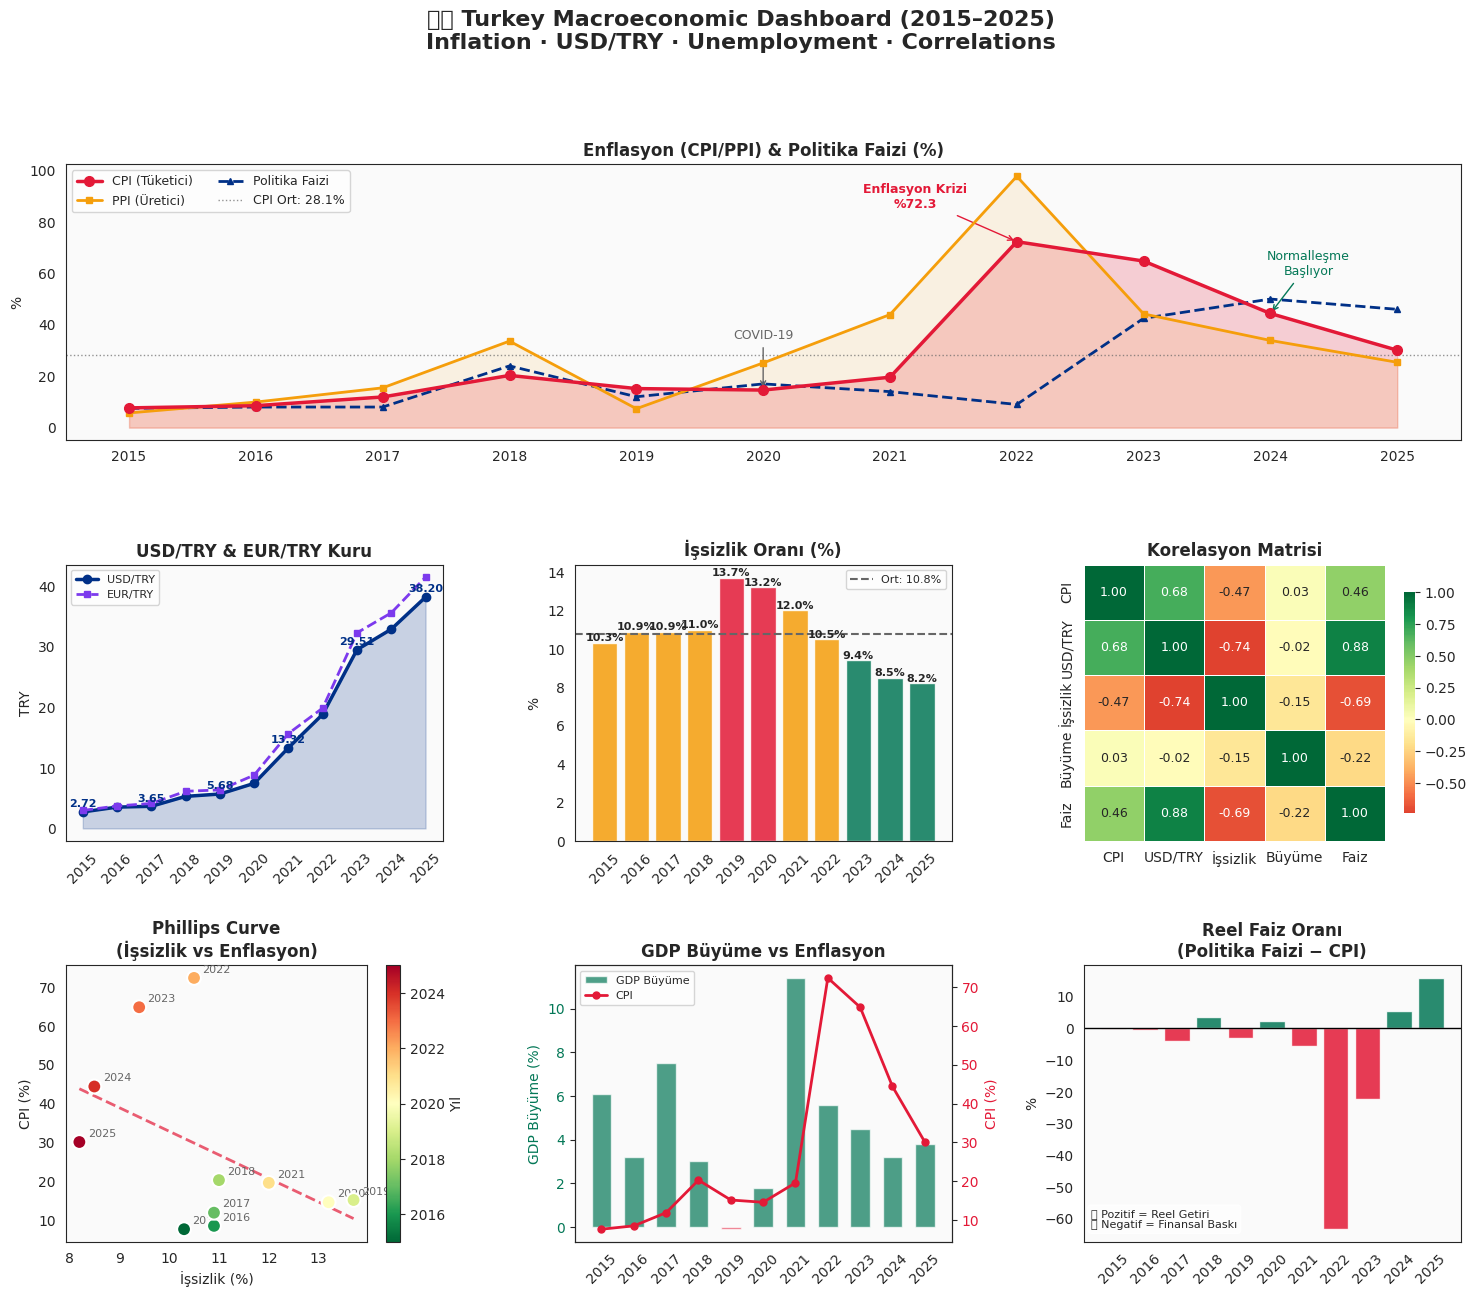

In [3]:
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

fig.suptitle('🇹🇷 Turkey Macroeconomic Dashboard (2015–2025)\nInflation · USD/TRY · Unemployment · Correlations',
             fontsize=16, fontweight='bold', y=0.99)

years = df['year'].values

# --- Grafik 1: Enflasyon ---
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(years, df['cpi'], alpha=0.2, color=RED)
ax1.fill_between(years, df['ppi'], alpha=0.1, color=ORANGE)
ax1.plot(years, df['cpi'], color=RED, linewidth=2.5,
         marker='o', markersize=7, label='CPI (Tüketici)', zorder=5)
ax1.plot(years, df['ppi'], color=ORANGE, linewidth=2,
         marker='s', markersize=5, label='PPI (Üretici)', zorder=4)
ax1.plot(years, df['policy_rate'], color=BLUE, linewidth=2,
         marker='^', markersize=5, linestyle='--', label='Politika Faizi')

# Kritik noktalar - dinamik koordinatlar (sabit değerler yerine df'den oku)
covid_cpi = df.loc[df['year'] == 2020, 'cpi'].values[0]
crisis_cpi = df.loc[df['year'] == 2022, 'cpi'].values[0]
norm_cpi = df.loc[df['year'] == 2024, 'cpi'].values[0]

ax1.annotate('COVID-19', xy=(2020, covid_cpi),
             xytext=(2020, covid_cpi + 20),
             arrowprops=dict(arrowstyle='->', color=GRAY),
             fontsize=9, color=GRAY, ha='center')
ax1.annotate(f'Enflasyon Krizi\n%{crisis_cpi:.1f}', xy=(2022, crisis_cpi),
             xytext=(2021.2, crisis_cpi + 13),
             arrowprops=dict(arrowstyle='->', color=RED),
             fontsize=9, color=RED, ha='center', fontweight='bold')
ax1.annotate('Normalleşme\nBaşlıyor', xy=(2024, norm_cpi),
             xytext=(2024.3, norm_cpi + 15),
             arrowprops=dict(arrowstyle='->', color=GREEN),
             fontsize=9, color=GREEN, ha='center')

ax1.axhline(y=df['cpi'].mean(), color=GRAY, linewidth=1,
            linestyle=':', alpha=0.7,
            label=f'CPI Ort: {df["cpi"].mean():.1f}%')
ax1.set_title('Enflasyon (CPI/PPI) & Politika Faizi (%)', fontweight='bold')
ax1.set_ylabel('%')
ax1.legend(loc='upper left', fontsize=9, ncol=2)   # ncol=4 → 2 (daha okunaklı)
ax1.set_facecolor('#fafafa')
ax1.set_xticks(years)

# --- Grafik 2: USD/TRY ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.fill_between(years, df['usd_try'], alpha=0.2, color=BLUE)
ax2.plot(years, df['usd_try'], color=BLUE, linewidth=2.5,
         marker='o', markersize=6, label='USD/TRY')          # ← label eklendi
ax2.plot(years, df['eur_try'], color=PURPLE, linewidth=2,
         marker='s', markersize=5, linestyle='--', label='EUR/TRY')
for year, val in zip(years[::2], df['usd_try'].values[::2]):
    ax2.text(year, val + 0.8, f'{val:.2f}',
             ha='center', fontsize=8, fontweight='bold', color=BLUE)
ax2.set_title('USD/TRY & EUR/TRY Kuru', fontweight='bold')
ax2.set_ylabel('TRY')
ax2.legend(fontsize=8, loc='upper left')
ax2.set_facecolor('#fafafa')
ax2.set_xticks(years)
ax2.tick_params(axis='x', rotation=45)

# --- Grafik 3: İşsizlik ---
ax3 = fig.add_subplot(gs[1, 1])
colors_unemp = [RED if u > 12 else ORANGE if u > 10 else GREEN
                for u in df['unemployment']]
bars = ax3.bar(years, df['unemployment'],
               color=colors_unemp, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, df['unemployment']):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')
ax3.axhline(y=df['unemployment'].mean(), color=GRAY,
            linewidth=1.5, linestyle='--',
            label=f'Ort: {df["unemployment"].mean():.1f}%')
ax3.set_title('İşsizlik Oranı (%)', fontweight='bold')
ax3.set_ylabel('%')
ax3.legend(fontsize=8)
ax3.set_facecolor('#fafafa')
ax3.set_xticks(years)
ax3.tick_params(axis='x', rotation=45)

# --- Grafik 4: Korelasyon Matrisi ---
ax4 = fig.add_subplot(gs[1, 2])
corr_cols = ['cpi', 'usd_try', 'unemployment', 'gdp_growth', 'policy_rate']
corr_labels = ['CPI', 'USD/TRY', 'İşsizlik', 'Büyüme', 'Faiz']
corr_matrix = df[corr_cols].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax4,
            linewidths=0.5, annot_kws={'size': 9},
            cbar_kws={'shrink': 0.8})
ax4.set_title('Korelasyon Matrisi', fontweight='bold')

# --- Grafik 5: Phillips Curve ---
ax5 = fig.add_subplot(gs[2, 0])
scatter = ax5.scatter(df['unemployment'], df['cpi'],
                      c=years, cmap='RdYlGn_r',
                      s=100, zorder=5, edgecolors='white', linewidth=1.5)
for year, u, c in zip(years, df['unemployment'], df['cpi']):
    ax5.annotate(str(year), (u, c),
                 textcoords="offset points",
                 xytext=(6, 4), fontsize=8, color=GRAY)
z = np.polyfit(df['unemployment'], df['cpi'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['unemployment'].min(), df['unemployment'].max(), 100)
ax5.plot(x_line, p(x_line), color=RED,
         linewidth=2, linestyle='--', alpha=0.7)
ax5.set_title('Phillips Curve\n(İşsizlik vs Enflasyon)', fontweight='bold')
ax5.set_xlabel('İşsizlik (%)')
ax5.set_ylabel('CPI (%)')
plt.colorbar(scatter, ax=ax5, label='Yıl')
ax5.set_facecolor('#fafafa')

# --- Grafik 6: GDP vs Enflasyon ---
ax6 = fig.add_subplot(gs[2, 1])
ax6_twin = ax6.twinx()
ax6.bar(years, df['gdp_growth'],
        color=[GREEN if g > 0 else RED for g in df['gdp_growth']],
        alpha=0.7, label='GDP Büyüme', width=0.6)         # 0.4 → 0.6 (daha görünür)
ax6_twin.plot(years, df['cpi'], color=RED, linewidth=2,
              marker='o', markersize=5, label='CPI')
ax6.set_title('GDP Büyüme vs Enflasyon', fontweight='bold')
ax6.set_ylabel('GDP Büyüme (%)', color=GREEN)
ax6_twin.set_ylabel('CPI (%)', color=RED)
ax6.tick_params(axis='y', labelcolor=GREEN)
ax6_twin.tick_params(axis='y', labelcolor=RED)
ax6.set_xticks(years)
ax6.tick_params(axis='x', rotation=45)
ax6.set_facecolor('#fafafa')
lines1, labels1 = ax6.get_legend_handles_labels()
lines2, labels2 = ax6_twin.get_legend_handles_labels()
ax6.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

# --- Grafik 7: Reel Faiz ---
# real_rate sütunu yoksa hesapla
if 'real_rate' not in df.columns:
    df['real_rate'] = df['policy_rate'] - df['cpi']

ax7 = fig.add_subplot(gs[2, 2])
colors_rr = [GREEN if r > 0 else RED for r in df['real_rate']]
bars7 = ax7.bar(years, df['real_rate'],
                color=colors_rr, alpha=0.85, edgecolor='white')
ax7.axhline(y=0, color='black', linewidth=1)
ax7.set_title('Reel Faiz Oranı\n(Politika Faizi − CPI)', fontweight='bold')
ax7.set_ylabel('%')
ax7.set_xticks(years)
ax7.tick_params(axis='x', rotation=45)
ax7.set_facecolor('#fafafa')
ax7.text(0.02, 0.05,
         '🟢 Pozitif = Reel Getiri\n🔴 Negatif = Finansal Baskı',
         transform=ax7.transAxes, fontsize=8,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.savefig('turkey_macro_dashboard.png', dpi=150, bbox_inches='tight')
from IPython.display import Image, display
display(Image('turkey_macro_dashboard.png'))
print("✅ Ana dashboard kaydedildi!")

In [4]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Tahmin yapılacak değişkenler
variables = {
    'cpi': {'name': 'Enflasyon (CPI)', 'color': RED, 'unit': '%'},
    'usd_try': {'name': 'USD/TRY', 'color': BLUE, 'unit': 'TRY'},
    'unemployment': {'name': 'İşsizlik', 'color': ORANGE, 'unit': '%'}
}

forecast_years = [2026, 2027, 2028, 2029, 2030]
n_forecast = len(forecast_years)
forecasts = {}

print("=" * 60)
print("📊 ARIMA TAHMİN SONUÇLARI (2026-2030)")
print("=" * 60)

for var, info in variables.items():
    series = df[var].values

    # ADF testi — durağanlık kontrolü
    adf_result = adfuller(series)
    is_stationary = adf_result[1] < 0.05

    # ARIMA modeli
    try:
        model = ARIMA(series, order=(1, 1, 1))
        fitted = model.fit()
        forecast = fitted.forecast(steps=n_forecast)
        conf_int = fitted.get_forecast(steps=n_forecast).conf_int()
    except:
        model = ARIMA(series, order=(1, 0, 0))
        fitted = model.fit()
        forecast = fitted.forecast(steps=n_forecast)
        conf_int = fitted.get_forecast(steps=n_forecast).conf_int()

    forecasts[var] = {
        'values': forecast,
        'lower': conf_int[:, 0],
        'upper': conf_int[:, 1],
        'info': info
    }

    print(f"\n📈 {info['name']}:")
    print(f"   Durağan: {'Evet' if is_stationary else 'Hayır'}")
    for year, val in zip(forecast_years, forecast):
        print(f"   {year}: {val:.2f} {info['unit']}")

📊 ARIMA TAHMİN SONUÇLARI (2026-2030)

📈 Enflasyon (CPI):
   Durağan: Hayır
   2026: 28.80 %
   2027: 27.81 %
   2028: 27.08 %
   2029: 26.52 %
   2030: 26.10 %

📈 USD/TRY:
   Durağan: Hayır
   2026: 42.55 TRY
   2027: 46.41 TRY
   2028: 49.82 TRY
   2029: 52.84 TRY
   2030: 55.51 TRY

📈 İşsizlik:
   Durağan: Hayır
   2026: 8.15 %
   2027: 8.14 %
   2028: 8.14 %
   2029: 8.14 %
   2030: 8.14 %


In [5]:
# ==========================================
# JEOPOLİTİK SENARYO ANALİZİ
# ==========================================

print("=" * 65)
print("📊 JEOPOLİTİK SENARYO ANALİZİ (2026-2030)")
print("=" * 65)
print("Baz: İran-İsrail-ABD körfez gerilimi düşük yoğunlukta devam")
print("=" * 65)

# Baz tahminler (ARIMA)
base_cpi = forecasts['cpi']['values']
base_usd = forecasts['usd_try']['values']
base_unemp = forecasts['unemployment']['values']

# ---- SENARYO 1: RISK (Çatışma Tırmanması) ----
# Petrol +20%, TL baskı, enflasyon yukarı, işsizlik artar
risk_cpi_shock   = [3.0, 5.0, 4.0, 3.0, 2.0]   # ek enflasyon pp
risk_usd_shock   = [4.0, 7.0, 6.0, 5.0, 4.0]   # ek TL değer kaybı
risk_unemp_shock = [0.5, 1.2, 1.5, 1.2, 1.0]   # ek işsizlik pp

risk_cpi   = [b + s for b, s in zip(base_cpi, risk_cpi_shock)]
risk_usd   = [b + s for b, s in zip(base_usd, risk_usd_shock)]
risk_unemp = [b + s for b, s in zip(base_unemp, risk_unemp_shock)]

# ---- SENARYO 2: POZİTİF (Ateşkes/Normalleşme) ----
# Risk iştahı geri döner, TL toparlar, enflasyon düşer
pos_cpi_shock   = [-2.0, -3.0, -3.5, -3.0, -2.5]
pos_usd_shock   = [-2.0, -3.5, -3.0, -2.5, -2.0]
pos_unemp_shock = [-0.3, -0.5, -0.7, -0.6, -0.5]

pos_cpi   = [max(b + s, 5.0) for b, s in zip(base_cpi, pos_cpi_shock)]
pos_usd   = [max(b + s, 35.0) for b, s in zip(base_usd, pos_usd_shock)]
pos_unemp = [max(b + s, 6.5) for b, s in zip(base_unemp, pos_unemp_shock)]

# ---- SENARYO 3: TAM SAVAŞ (Kuyruk Riski) ----
# Körfez kapanır, petrol +50%, stagflasyon
war_cpi_shock   = [8.0, 15.0, 12.0, 8.0, 6.0]
war_usd_shock   = [8.0, 18.0, 15.0, 12.0, 10.0]
war_unemp_shock = [1.5, 3.0, 4.0, 3.5, 3.0]

war_cpi   = [b + s for b, s in zip(base_cpi, war_cpi_shock)]
war_usd   = [b + s for b, s in zip(base_usd, war_usd_shock)]
war_unemp = [b + s for b, s in zip(base_unemp, war_unemp_shock)]

# Sonuçları yazdır
print(f"\n{'Yıl':<6} {'Base CPI':>10} {'Risk CPI':>10} {'Pozitif CPI':>12} {'Savaş CPI':>10}")
print("-" * 52)
for i, year in enumerate(forecast_years):
    print(f"{year:<6} {base_cpi[i]:>9.1f}% {risk_cpi[i]:>9.1f}% "
          f"{pos_cpi[i]:>11.1f}% {war_cpi[i]:>9.1f}%")

print(f"\n{'Yıl':<6} {'Base USD':>10} {'Risk USD':>10} {'Pozitif USD':>12} {'Savaş USD':>10}")
print("-" * 52)
for i, year in enumerate(forecast_years):
    print(f"{year:<6} {base_usd[i]:>9.2f} {risk_usd[i]:>9.2f} "
          f"{pos_usd[i]:>11.2f} {war_usd[i]:>9.2f}")

print(f"\n{'Yıl':<6} {'Base İş':>10} {'Risk İş':>10} {'Pozitif İş':>12} {'Savaş İş':>10}")
print("-" * 52)
for i, year in enumerate(forecast_years):
    print(f"{year:<6} {base_unemp[i]:>9.1f}% {risk_unemp[i]:>9.1f}% "
          f"{pos_unemp[i]:>11.1f}% {war_unemp[i]:>9.1f}%")

print(f"\n⚠️  SENARYO AÇIKLAMALARI:")
print(f"   Base    : Körfez gerilimi düşük yoğunlukta devam (mevcut trend)")
print(f"   Risk    : Çatışma tırmanır, petrol +20%, TL baskı altında")
print(f"   Pozitif : Ateşkes/normalleşme, risk iştahı geri döner")
print(f"   Savaş   : Tam çatışma (kuyruk riski), stagflasyon senaryosu")

📊 JEOPOLİTİK SENARYO ANALİZİ (2026-2030)
Baz: İran-İsrail-ABD körfez gerilimi düşük yoğunlukta devam

Yıl      Base CPI   Risk CPI  Pozitif CPI  Savaş CPI
----------------------------------------------------
2026        28.8%      31.8%        26.8%      36.8%
2027        27.8%      32.8%        24.8%      42.8%
2028        27.1%      31.1%        23.6%      39.1%
2029        26.5%      29.5%        23.5%      34.5%
2030        26.1%      28.1%        23.6%      32.1%

Yıl      Base USD   Risk USD  Pozitif USD  Savaş USD
----------------------------------------------------
2026       42.55     46.55       40.55     50.55
2027       46.41     53.41       42.91     64.41
2028       49.82     55.82       46.82     64.82
2029       52.84     57.84       50.34     64.84
2030       55.51     59.51       53.51     65.51

Yıl       Base İş    Risk İş   Pozitif İş   Savaş İş
----------------------------------------------------
2026         8.1%       8.6%         7.8%       9.6%
2027         8.

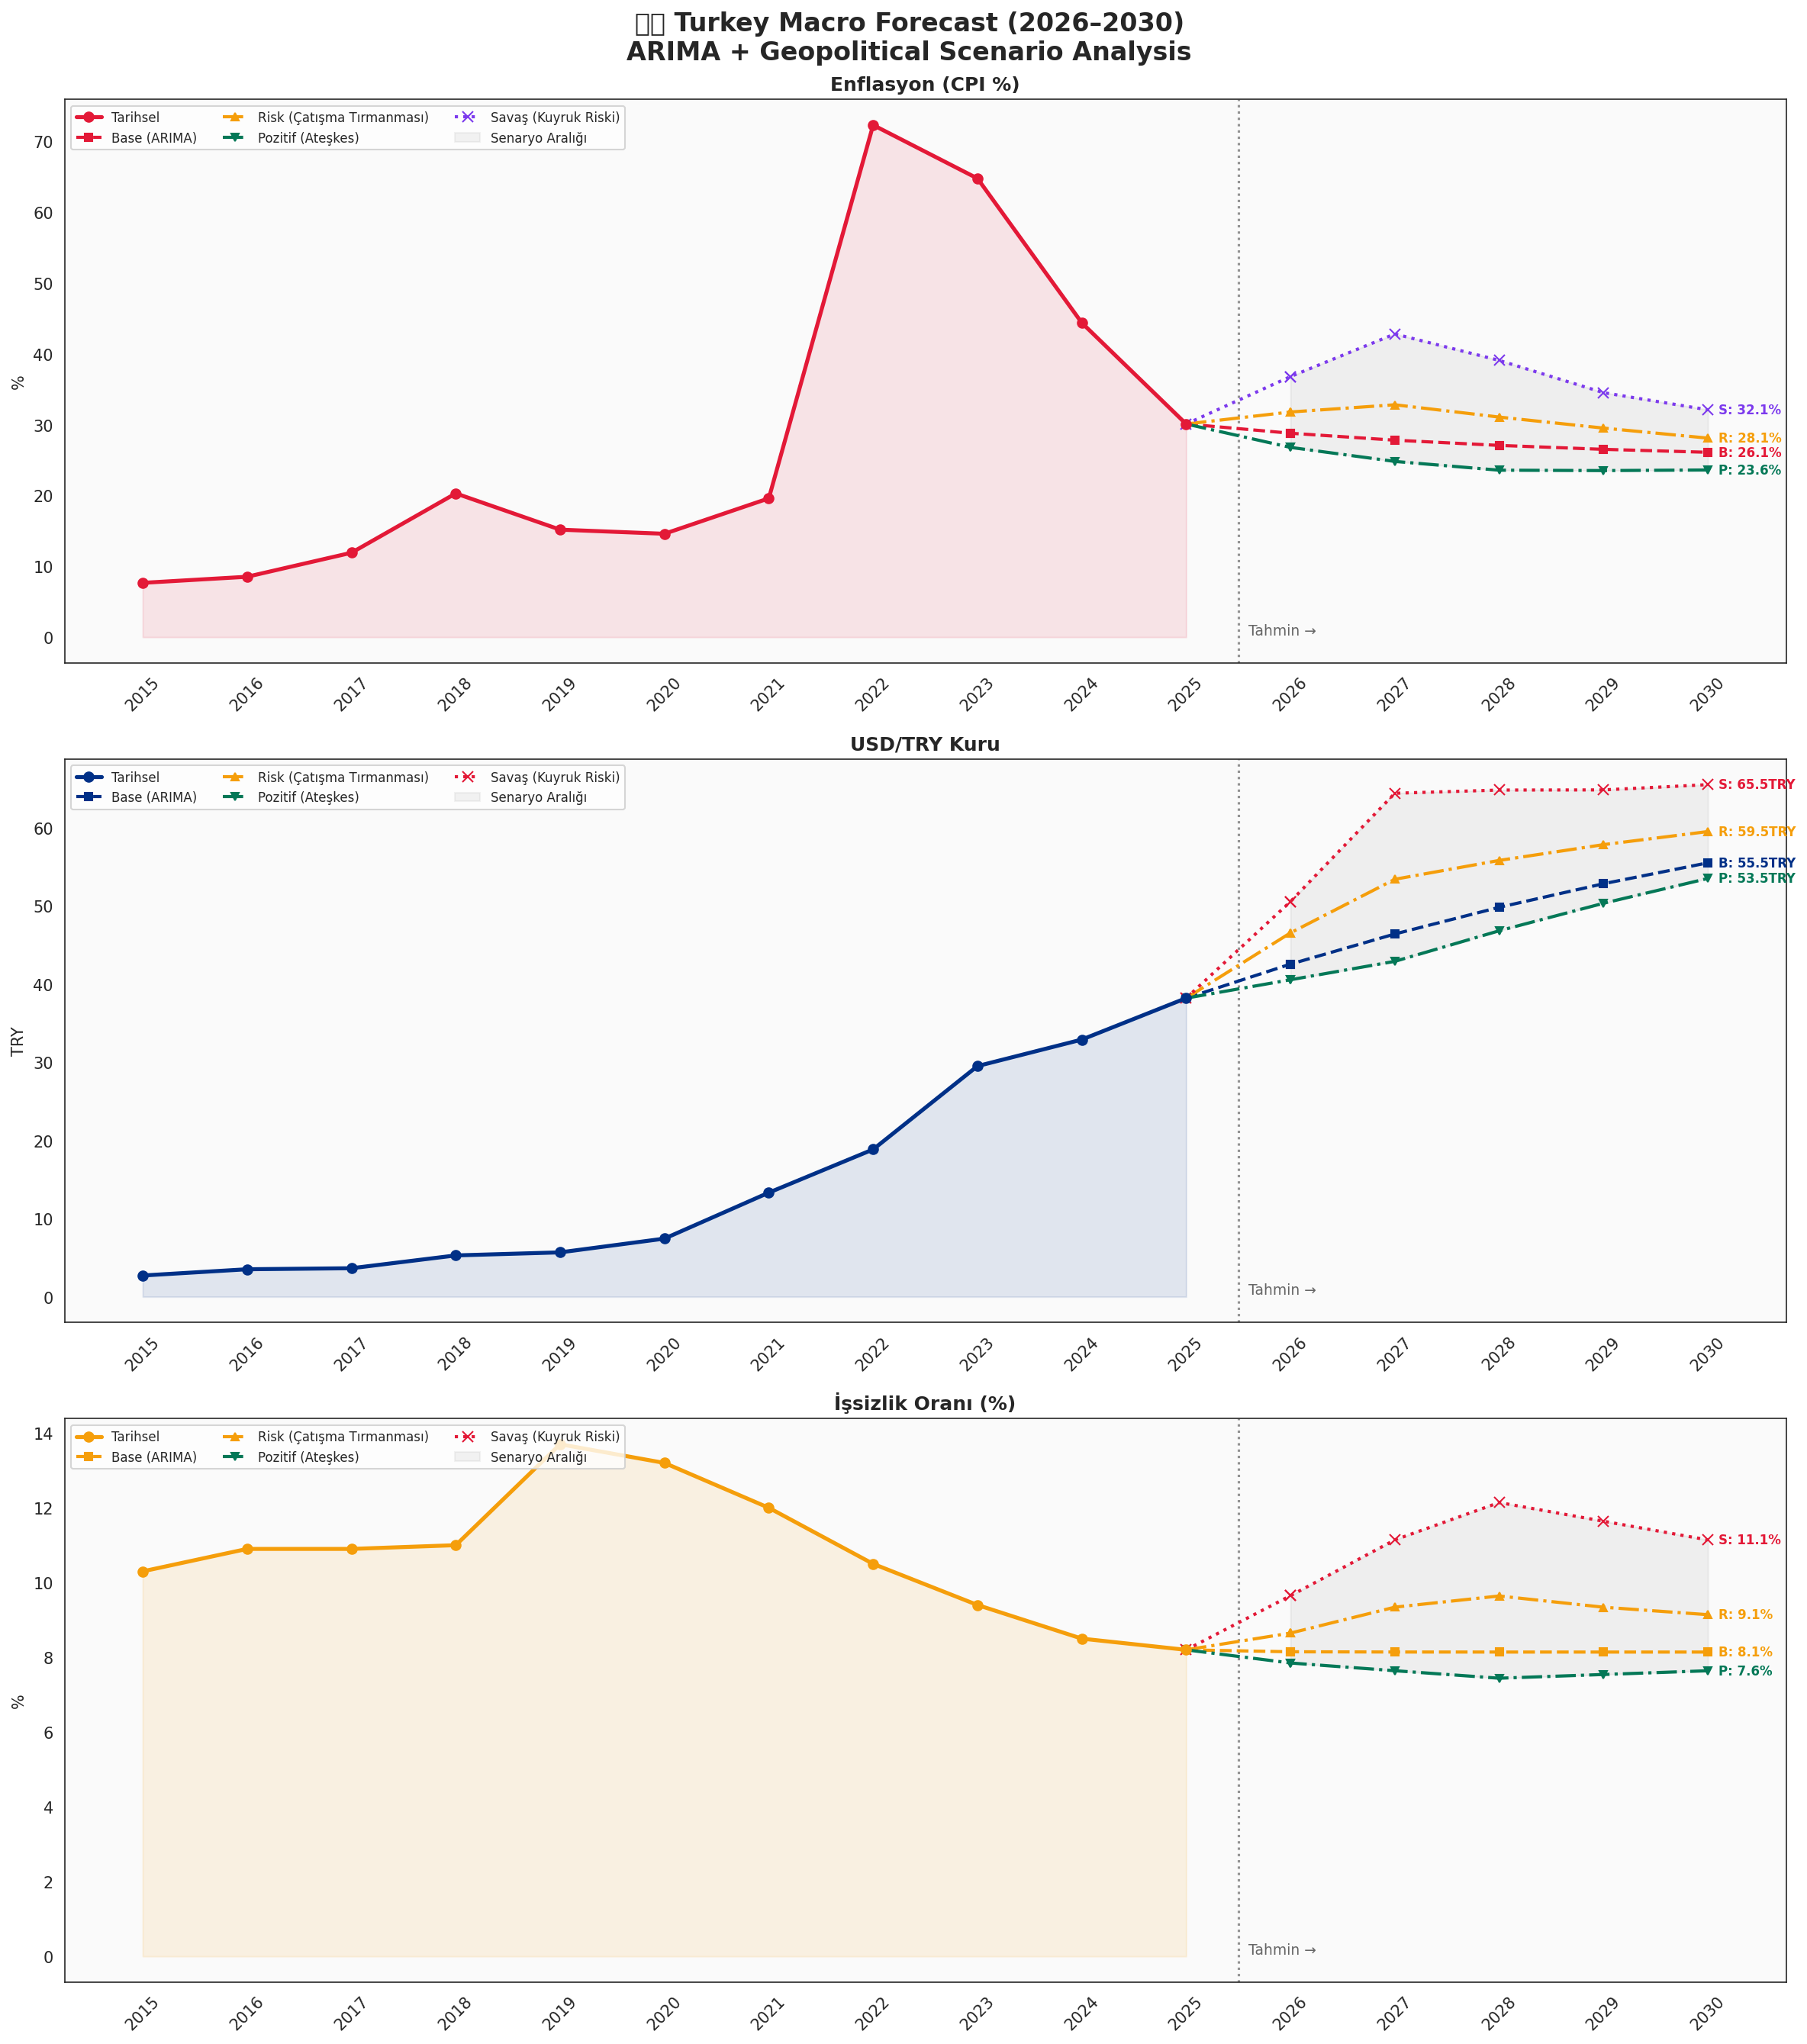

✅ Forecast grafiği kaydedildi!


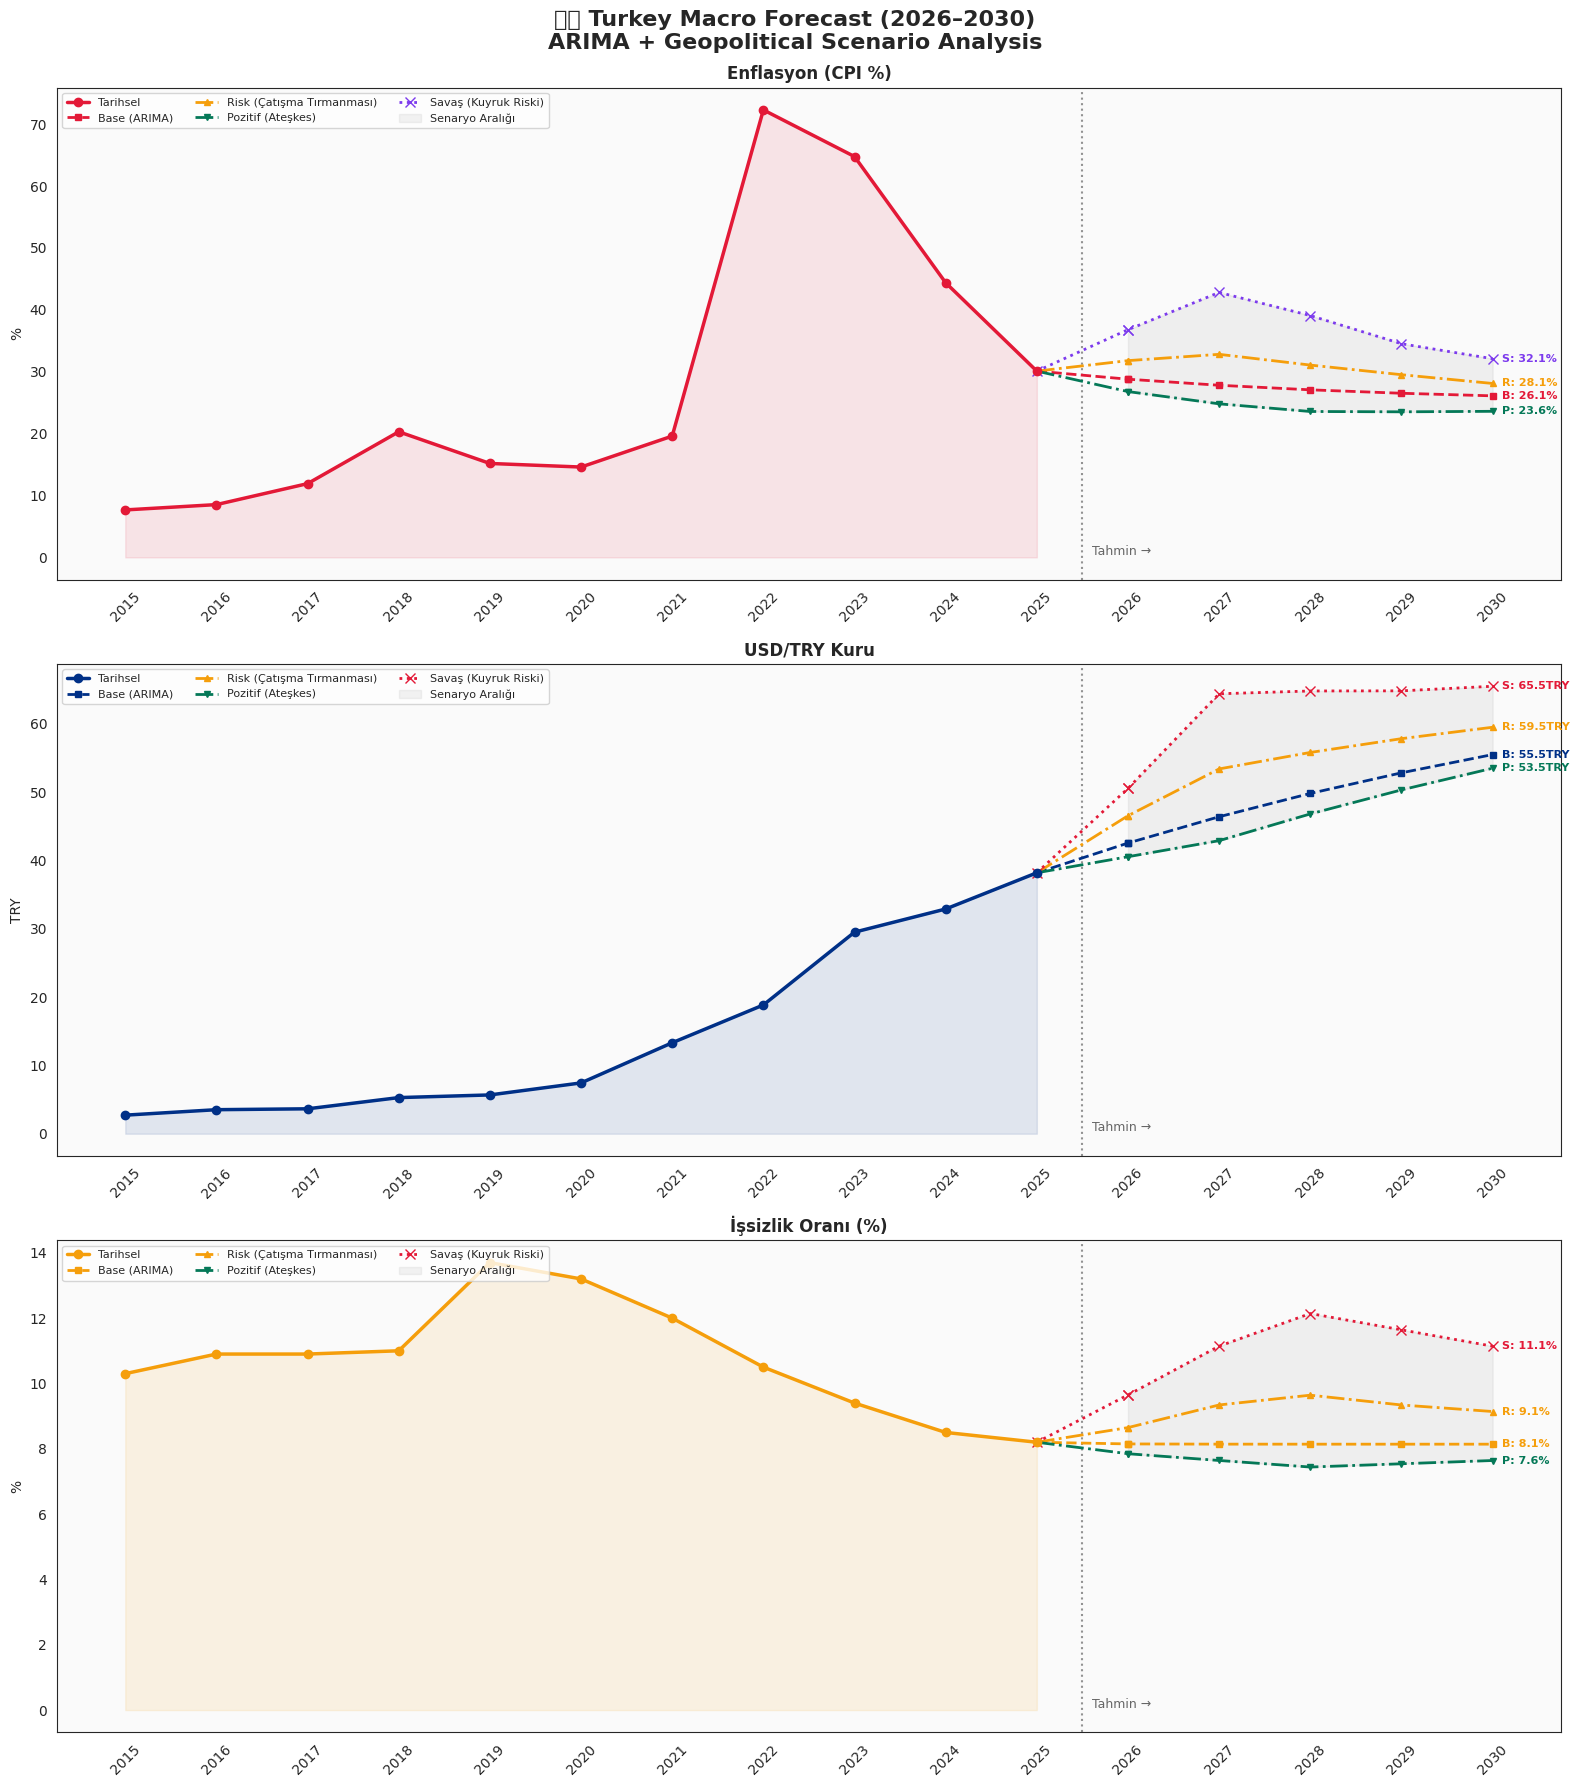

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.patch.set_facecolor('white')
fig.suptitle('🇹🇷 Turkey Macro Forecast (2026–2030)\nARIMA + Geopolitical Scenario Analysis',
             fontsize=16, fontweight='bold', y=0.99)

hist_years = df['year'].values
all_years = np.concatenate([hist_years, forecast_years])

for ax, (var, base, risk, pos, war, title, unit, color) in zip(axes, [
    ('cpi', base_cpi, risk_cpi, pos_cpi, war_cpi, 'Enflasyon (CPI %)', '%', RED),
    ('usd_try', base_usd, risk_usd, pos_usd, war_usd, 'USD/TRY Kuru', 'TRY', BLUE),
    ('unemployment', base_unemp, risk_unemp, pos_unemp, war_unemp, 'İşsizlik Oranı (%)', '%', ORANGE),
]):
    hist_vals = df[var].values

    # Tarihsel veri
    ax.plot(hist_years, hist_vals, color=color, linewidth=2.5,
            marker='o', markersize=6, label='Tarihsel', zorder=5)
    ax.fill_between(hist_years, hist_vals, alpha=0.1, color=color)

    # Bağlantı noktası
    connect_x = [hist_years[-1], forecast_years[0]]
    connect_y_base = [hist_vals[-1], base[0]]
    connect_y_risk = [hist_vals[-1], risk[0]]
    connect_y_pos  = [hist_vals[-1], pos[0]]
    connect_y_war  = [hist_vals[-1], war[0]]

    # Senaryo çizgileri
    ax.plot(connect_x + list(forecast_years),
            connect_y_base + list(base),
            color=color, linewidth=2, linestyle='--',
            marker='s', markersize=5, label='Base (ARIMA)', zorder=4)

    ax.plot(connect_x + list(forecast_years),
            connect_y_risk + list(risk),
            color=ORANGE, linewidth=2, linestyle='-.',
            marker='^', markersize=5, label='Risk (Çatışma Tırmanması)', zorder=4)

    ax.plot(connect_x + list(forecast_years),
            connect_y_pos + list(pos),
            color=GREEN, linewidth=2, linestyle='-.',
            marker='v', markersize=5, label='Pozitif (Ateşkes)', zorder=4)

    ax.plot(connect_x + list(forecast_years),
            connect_y_war + list(war),
            color=RED if color != RED else PURPLE,
            linewidth=2, linestyle=':',
            marker='x', markersize=7, label='Savaş (Kuyruk Riski)', zorder=4)

    # Bant dolgu
    ax.fill_between(forecast_years, pos, war,
                    alpha=0.08, color=GRAY, label='Senaryo Aralığı')

    # Dikey ayraç
    ax.axvline(x=2025.5, color=GRAY, linewidth=1.5,
               linestyle=':', alpha=0.7)
    ax.text(2025.6, ax.get_ylim()[0] + (ax.get_ylim()[1]-ax.get_ylim()[0])*0.05,
            'Tahmin →', fontsize=9, color=GRAY)

    # Son değer etiketleri
    for vals, col, label in [
        (base, color, 'B'),
        (risk, ORANGE, 'R'),
        (pos, GREEN, 'P'),
        (war, RED if color != RED else PURPLE, 'S')
    ]:
        ax.text(forecast_years[-1] + 0.1, vals[-1],
                f'{label}: {vals[-1]:.1f}{unit}',
                fontsize=8, color=col, va='center', fontweight='bold')

    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel(unit)
    ax.legend(loc='upper left', fontsize=8, ncol=3)
    ax.set_facecolor('#fafafa')
    ax.set_xticks(list(hist_years) + forecast_years)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('turkey_macro_forecast.png', dpi=150, bbox_inches='tight')
from IPython.display import Image, display
display(Image('turkey_macro_forecast.png'))
print("✅ Forecast grafiği kaydedildi!")

In [7]:
from google.colab import files

files.download('turkey_macro_dashboard.png')
files.download('turkey_macro_forecast.png')
print("✅ Tüm grafikler indirildi!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Tüm grafikler indirildi!
